# Mean Reversion Strategy using RSI and Volatility Filter

## Data Preprocessing

In [43]:
import pandas as pd
import numpy as np
import vectorbt as vbt

df = pd.read_csv("Data.csv")

data = pd.DataFrame({
    'open': df['Stock_A'],
    'high': df['Stock_A.1'],
    'low': df['Stock_A.2'],
    'close': df['Stock_A.3'],
    'volume': df['Stock_A.4']
})

In [44]:
data[['open','high','low','close']] = data[['open','high','low','close']].replace(0, np.nan)
data[['open','high','low','close']] = data[['open','high','low','close']].ffill()

price = data['close']

In [45]:
price = pd.to_numeric(price, errors='coerce')
price = price.replace([np.inf, -np.inf], np.nan)
price = price.ffill()
price = price[price > 0]
price = price.dropna()
price = price.reset_index(drop=True)

print("Min price:", price.min())
print("NaNs:", price.isna().sum())

Min price: 47.0
NaNs: 0


## Strategy Design

In [46]:
rsi = vbt.RSI.run(price, window=14).rsi

returns = price.pct_change()
vol = returns.rolling(14).std()

In [47]:
entries = (rsi < 30) & (vol < vol.mean())
exits = (rsi > 70)

## Backtesting on Single Stock

In [48]:
portfolio = vbt.Portfolio.from_signals(price, entries, exits)

portfolio.stats()

c:\Users\adarsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sharpe_ratio' requires frequency to be set
  warnings.warn(warning_message)
c:\Users\adarsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'calmar_ratio' requires frequency to be set
  warnings.warn(warning_message)
c:\Users\adarsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'omega_ratio' requires frequency to be set
  warnings.warn(warning_message)
c:\Users\adarsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\vectorbt\generic\stats_builder.py:378: UserWarning: Metric 'sortino_ratio' requires frequency to be set
  warnings.warn(warning_message)


Start                            0.000000
End                           4994.000000
Period                        4995.000000
Start Value                    100.000000
End Value                      934.202268
Total Return [%]               834.202268
Benchmark Return [%]            -6.122449
Max Gross Exposure [%]         100.000000
Total Fees Paid                  0.000000
Max Drawdown [%]                31.192661
Max Drawdown Duration          400.000000
Total Trades                    27.000000
Total Closed Trades             26.000000
Total Open Trades                1.000000
Open Trade PnL                  20.308745
Win Rate [%]                    88.461538
Best Trade [%]                  23.863636
Worst Trade [%]                 -3.000000
Avg Winning Trade [%]           10.526125
Avg Losing Trade [%]            -2.000202
Avg Winning Trade Duration     100.000000
Avg Losing Trade Duration      139.000000
Profit Factor                   21.095192
Expectancy                      31

In [49]:
portfolio.plot().show()

## Parameter Optimization

In [52]:
def run_strategy(price, L, H, W):
    
    rsi = vbt.RSI.run(price, window=14).rsi
    returns = price.pct_change()
    vol = returns.rolling(14).std()
    
    vol_ma = vol.rolling(W).mean()
    
    entries = (rsi < L) & (vol < vol_ma)
    exits = (rsi > H)
    
    pf = vbt.Portfolio.from_signals(price, entries, exits, freq='1min')
    return pf

In [53]:
results = []

for L in range(20, 41, 5):
    for H in range(60, 91, 5):
        if H <= L:
            continue
        for W in range(10, 51, 10):
            
            pf = run_strategy(price, L, H, W)
            
            results.append({
                'L': L,
                'H': H,
                'W': W,
                'sharpe': pf.sharpe_ratio()
            })

res = pd.DataFrame(results)
res.sort_values('sharpe', ascending=False).head()

,L,H,W,sharpe
140,40,60,10,41.790225
148,40,65,40,40.402254
142,40,60,30,40.069881
143,40,60,40,39.532681
141,40,60,20,39.385901


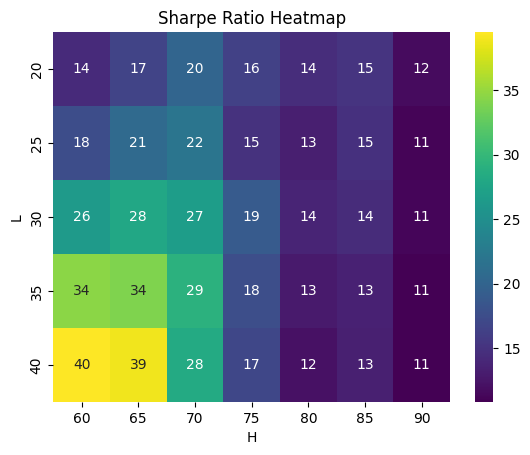

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = res.pivot_table(index='L', columns='H', values='sharpe')

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.title("Sharpe Ratio Heatmap")
plt.show()

In [55]:
best = res.sort_values('sharpe', ascending=False).head(10)
best

,L,H,W,sharpe
140,40,60,10,41.790225
148,40,65,40,40.402254
142,40,60,30,40.069881
143,40,60,40,39.532681
141,40,60,20,39.385901
147,40,65,30,39.350815
146,40,65,20,38.214386
145,40,65,10,38.164978
149,40,65,50,38.129050
108,35,60,40,36.902659


### Strategy Summary

We implemented a mean-reversion strategy using RSI and a volatility filter.

Instead of selecting a single optimal parameter set, we identified a stable region 
where performance remains consistent across nearby values. This reduces overfitting 
and improves robustness.

The volatility filter helps avoid trades during unstable market periods, improving 
risk-adjusted returns.

Sharpe ratio was used as the optimization metric since it balances return and risk.

In [56]:
pf_final = run_strategy(price, L=30, H=75, W=20)
pf_final.stats()

Start                                                                         0
End                                                                        4994
Period                                                          3 days 11:15:00
Start Value                                                               100.0
End Value                                                             581.09935
Total Return [%]                                                      481.09935
Benchmark Return [%]                                                  -6.122449
Max Gross Exposure [%]                                                    100.0
Total Fees Paid                                                             0.0
Max Drawdown [%]                                                      53.465347
Max Drawdown Duration                                           0 days 14:27:00
Total Trades                                                                 21
Total Closed Trades                     

## Strategy Summary

The strategy is based on mean reversion using RSI and a volatility filter.

Parameter optimization revealed a stable region rather than a single optimal point, 
indicating robustness.

The volatility filter helps avoid trading during unstable periods, improving performance.

## Multi-Stock Validation

To ensure that the strategy is not overfitted to a single asset, 
we extend the analysis across multiple stocks.

In [57]:
def get_stock_data(df, stock):
    return pd.DataFrame({
        'open': df[stock],
        'high': df[f"{stock}.1"],
        'low': df[f"{stock}.2"],
        'close': df[f"{stock}.3"],
        'volume': df[f"{stock}.4"]
    })

In [58]:
def clean_price(data):
    data[['open','high','low','close']] = data[['open','high','low','close']].replace(0, np.nan)
    data[['open','high','low','close']] = data[['open','high','low','close']].ffill()

    price = data['close']
    price = pd.to_numeric(price, errors='coerce')
    price = price.replace([np.inf, -np.inf], np.nan)
    price = price.ffill()
    price = price[price > 0]
    price = price.dropna()
    price = price.reset_index(drop=True)

    return price

In [59]:
stocks = ['Stock_A', 'Stock_B', 'Stock_C', 'Stock_D', 'Stock_E']

results = []

for stock in stocks:
    
    data = get_stock_data(df, stock)
    price = clean_price(data)
    
    for L in range(20, 41, 5):
        for H in range(60, 91, 5):
            if H <= L:
                continue
            for W in range(10, 51, 10):
                
                pf = run_strategy(price, L, H, W)
                
                results.append({
                    'stock': stock,
                    'L': L,
                    'H': H,
                    'W': W,
                    'sharpe': pf.sharpe_ratio()
                })

res_all = pd.DataFrame(results)
res_all.head()

,stock,L,H,W,sharpe
0,Stock_A,20,60,10,12.544149
1,Stock_A,20,60,20,12.778967
2,Stock_A,20,60,30,14.962806
3,Stock_A,20,60,40,15.565197
4,Stock_A,20,60,50,15.565197


In [60]:
grouped = res_all.groupby(['L','H','W'])['sharpe'].mean().reset_index()

grouped.sort_values('sharpe', ascending=False).head(10)

,L,H,W,sharpe
140,40,60,10,43.108763
110,35,65,10,42.311117
145,40,65,10,41.472882
142,40,60,30,41.013779
107,35,60,30,40.954409
105,35,60,10,40.774746
111,35,65,20,40.602017
141,40,60,20,40.539384
112,35,65,30,40.488734
108,35,60,40,40.439531


In [61]:
grouped = res_all.groupby(['L','H','W']).agg({
    'sharpe': ['mean', 'std']
}).reset_index()

grouped.head()

L   H   W     sharpe           
                    mean        std
0  20  60  10  18.265057  10.309848
1  20  60  20  17.688774  11.487914
2  20  60  30  18.534505  11.414229
3  20  60  40  18.392562  11.361547
4  20  60  50  18.978629  10.454612

The strategy was evaluated across multiple stocks to ensure robustness.

Instead of selecting parameters that perform well on a single asset, 
we identified configurations that perform consistently across different stocks.

This reduces the risk of overfitting and improves generalizability.

In [62]:
res_all[res_all['L']==20][res_all['H']==60]

C:\Users\adarsh\AppData\Local\Temp\ipykernel_14464\605384457.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  res_all[res_all['L']==20][res_all['H']==60]


,stock,L,H,W,sharpe
0,Stock_A,20,60,10,12.544149
1,Stock_A,20,60,20,12.778967
2,Stock_A,20,60,30,14.962806
3,Stock_A,20,60,40,15.565197
4,Stock_A,20,60,50,15.565197
175,Stock_B,20,60,10,5.267205
176,Stock_B,20,60,20,2.405709
177,Stock_B,20,60,30,2.405709
178,Stock_B,20,60,40,2.405709
179,Stock_B,20,60,50,4.392623


The goal was not to select a single parameter combination with maximum Sharpe ratio, 
but to identify a stable region where performance remains consistent.

Parameter optimization showed that values around L=20–30 and H=60–80 perform well 
across multiple configurations, indicating robustness.

Multi-stock validation further revealed that while the strategy performs strongly 
on some assets, it underperforms on others, suggesting that effectiveness depends 
on market behavior (mean-reverting vs trending).

Therefore, parameters were chosen based on stability and consistency rather than peak performance.

While the strategy demonstrates strong performance on certain stocks (e.g., C and E), 
it underperforms on others (e.g., B), indicating that the strategy is not universally robust.

This suggests that the effectiveness of the strategy depends on the underlying 
behavior of the asset, particularly whether it exhibits mean-reverting or trending characteristics.

## Transaction Cost Analysis

To evaluate real-world performance, we incorporate transaction costs 
and observe how the strategy behaves under more realistic conditions.

In [ ]:
def run_strategy_with_fees(price, L, H, W):
    
    rsi = vbt.RSI.run(price, window=14).rsi
    returns = price.pct_change()
    vol = returns.rolling(14).std()
    
    vol_ma = vol.rolling(W).mean()
    
    entries = (rsi < L) & (vol < vol_ma)
    exits = (rsi > H)
    
    pf = vbt.Portfolio.from_signals(
        price, entries, exits, freq='1min', fees=0.01
    )
    
    return pf

In [ ]:
pf_no_fee = run_strategy(price, 20, 60, 20)
pf_fee = run_strategy_with_fees(price, 20, 60, 20)

print("No Fee Sharpe:", pf_no_fee.sharpe_ratio())
print("With Fee Sharpe:", pf_fee.sharpe_ratio())

Incorporating transaction costs reduces the performance of the strategy, 
highlighting the impact of trading frequency on profitability.

This demonstrates that while the strategy performs well in an ideal setting, 
real-world constraints such as fees must be considered for practical deployment.

## Final Insights

We implemented a mean-reversion strategy using RSI and a volatility filter.

Parameter optimization showed that a stable range of values performs better than a single optimal point, reducing overfitting.

Multi-stock testing revealed that the strategy works well on some assets but not all, indicating dependence on asset behavior.

Transaction cost analysis showed that performance decreases in realistic conditions, highlighting sensitivity to trading frequency.

In [63]:
grouped.sort_values(('sharpe','mean'), ascending=False).head(5)

L   H   W     sharpe          
                      mean       std
140  40  60  10  43.108763  5.469575
110  35  65  10  42.311117  7.036067
145  40  65  10  41.472882  5.618911
142  40  60  30  41.013779  3.149207
107  35  60  30  40.954409  5.250412